# Extractive Question Answering

## Overview

**Extractive Question Answering** is a core NLP task where we find the answer to a question by extracting a span of text from a given context paragraph. Unlike generative QA (which generates new text), extractive QA simply identifies where in the context the answer already exists.

**What we'll learn:**
- How extractive QA differs from other QA approaches
- The SQuAD dataset format and task formulation
- Building attention mechanisms from scratch (BiDAF)
- Using BERT for production-quality QA
- Evaluation metrics (Exact Match, F1)
- Advanced topics (impossible questions, multi-hop reasoning)

**Why it matters:**
- Foundation for search engines and virtual assistants
- Teaches bidirectional attention patterns
- Shows how transformers excel at span prediction
- Used in real-world applications (customer support, document search)

## Setup

Import required libraries and configure the environment.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass
import re
import string
from collections import Counter
from transformers import BertTokenizerFast, BertForQuestionAnswering

from aiml_notebooks import get_device, set_seed

%load_ext autoreload
%autoreload 2

Set random seed for reproducibility and configure device.

In [2]:
set_seed(42)
device = get_device(prefer_cpu=True)  # BERT works best on CUDA/CPU
print(f"Using device: {device}")

Using CPU
Note: MPS is available but not used due to compatibility issues
To use MPS with CPU fallback, run: PYTORCH_ENABLE_MPS_FALLBACK=1 jupyter lab
Using device: cpu


## 1. What is Extractive Question Answering?

### The Task

Given a **question** and a **context** paragraph, identify the **start** and **end** positions of the answer span within the context.

**Example:**
- Context: "The Eiffel Tower was completed in 1889 for the World's Fair."
- Question: "When was the Eiffel Tower completed?"
- Answer: "1889" (positions 33-37)

**Key differences:**
- **Extractive QA**: Answer must be a substring of the context
- **Generative QA**: Model generates new text (not limited to context)
- **Multiple-choice QA**: Select from predefined options
- **Open-domain QA**: Retrieval + reading comprehension

Create a simple example to illustrate the task.

In [3]:
@dataclass
class QAExample:
    """Single QA example with context, question, and answer span."""
    context: str
    question: str
    answer_text: str
    answer_start: int
    
    @property
    def answer_end(self) -> int:
        return self.answer_start + len(self.answer_text)
    
    def __str__(self):
        return f"Question: {self.question}\nContext: {self.context}\nAnswer: '{self.answer_text}' (pos {self.answer_start}-{self.answer_end})"

# Create example
example = QAExample(
    context="The Eiffel Tower was completed in 1889 for the World's Fair in Paris.",
    question="When was the Eiffel Tower completed?",
    answer_text="1889",
    answer_start=33
)

print(example)
print(f"\nVerification: '{example.context[example.answer_start:example.answer_end]}'")

Question: When was the Eiffel Tower completed?
Context: The Eiffel Tower was completed in 1889 for the World's Fair in Paris.
Answer: '1889' (pos 33-37)

Verification: ' 188'


### SQuAD Dataset Format

The **Stanford Question Answering Dataset (SQuAD)** is the standard benchmark for extractive QA.

**SQuAD 1.1**: All questions have answers in the context
**SQuAD 2.0**: Includes "impossible" questions (no answer in context)

Each example contains:
- `context`: Paragraph of text
- `question`: Natural language question
- `answers`: List of possible answers (may have multiple valid spans)
- `is_impossible`: Boolean (SQuAD 2.0 only)

Create a small synthetic dataset in SQuAD format.

In [4]:
# Synthetic QA dataset
qa_data = [
    QAExample(
        context="The Eiffel Tower was completed in 1889 for the World's Fair in Paris.",
        question="When was the Eiffel Tower completed?",
        answer_text="1889",
        answer_start=33
    ),
    QAExample(
        context="The Eiffel Tower was completed in 1889 for the World's Fair in Paris.",
        question="Where is the Eiffel Tower located?",
        answer_text="Paris",
        answer_start=63
    ),
    QAExample(
        context="Python was created by Guido van Rossum in 1991 as a high-level programming language.",
        question="Who created Python?",
        answer_text="Guido van Rossum",
        answer_start=22
    ),
    QAExample(
        context="Python was created by Guido van Rossum in 1991 as a high-level programming language.",
        question="When was Python created?",
        answer_text="1991",
        answer_start=43
    ),
    QAExample(
        context="The Transformer architecture was introduced in 2017 by researchers at Google.",
        question="When was the Transformer introduced?",
        answer_text="2017",
        answer_start=46
    ),
    QAExample(
        context="The Transformer architecture was introduced in 2017 by researchers at Google.",
        question="Where were the Transformer researchers from?",
        answer_text="Google",
        answer_start=71
    ),
]

print(f"Created {len(qa_data)} QA examples")
print(f"\nExample 0:\n{qa_data[0]}")

Created 6 QA examples

Example 0:
Question: When was the Eiffel Tower completed?
Context: The Eiffel Tower was completed in 1889 for the World's Fair in Paris.
Answer: '1889' (pos 33-37)


## 2. Simple Baseline: TF-IDF + Keyword Matching

### Heuristic Approach

Before diving into neural models, let's build a simple baseline:
1. Split context into sentences
2. Compute TF-IDF similarity between question and each sentence
3. Return the most similar sentence as the answer

This shows why neural models are needed - simple heuristics struggle with semantic understanding.

Implement TF-IDF vectorizer from scratch.

In [5]:
def tokenize(text: str) -> List[str]:
    """Simple tokenizer: lowercase and remove punctuation."""
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text.split()

def compute_tf(tokens: List[str]) -> Dict[str, float]:
    """Compute term frequency."""
    tf = Counter(tokens)
    total = len(tokens)
    return {word: count / total for word, count in tf.items()}

def compute_idf(documents: List[List[str]]) -> Dict[str, float]:
    """Compute inverse document frequency."""
    n_docs = len(documents)
    word_doc_count = Counter()
    
    for doc in documents:
        unique_words = set(doc)
        for word in unique_words:
            word_doc_count[word] += 1
    
    return {word: np.log(n_docs / count) for word, count in word_doc_count.items()}

# Test on example
test_text = "The Eiffel Tower was completed in 1889"
tokens = tokenize(test_text)
print(f"Tokens: {tokens}")
print(f"TF: {compute_tf(tokens)}")

Tokens: ['the', 'eiffel', 'tower', 'was', 'completed', 'in', '1889']
TF: {'the': 0.14285714285714285, 'eiffel': 0.14285714285714285, 'tower': 0.14285714285714285, 'was': 0.14285714285714285, 'completed': 0.14285714285714285, 'in': 0.14285714285714285, '1889': 0.14285714285714285}


Implement TF-IDF based QA baseline.

In [6]:
class TfidfQABaseline:
    """Simple TF-IDF based QA system."""
    
    def __init__(self):
        self.idf = None
    
    def fit(self, contexts: List[str]):
        """Compute IDF from contexts."""
        documents = [tokenize(ctx) for ctx in contexts]
        self.idf = compute_idf(documents)
    
    def get_tfidf_vector(self, text: str) -> Dict[str, float]:
        """Compute TF-IDF vector for text."""
        tokens = tokenize(text)
        tf = compute_tf(tokens)
        
        tfidf = {}
        for word, tf_val in tf.items():
            idf_val = self.idf.get(word, 0.0)
            tfidf[word] = tf_val * idf_val
        return tfidf
    
    def cosine_similarity(self, vec1: Dict[str, float], vec2: Dict[str, float]) -> float:
        """Compute cosine similarity between two vectors."""
        # Get common words
        all_words = set(vec1.keys()) | set(vec2.keys())
        
        # Compute dot product and magnitudes
        dot_product = sum(vec1.get(w, 0) * vec2.get(w, 0) for w in all_words)
        mag1 = np.sqrt(sum(v**2 for v in vec1.values()))
        mag2 = np.sqrt(sum(v**2 for v in vec2.values()))
        
        if mag1 == 0 or mag2 == 0:
            return 0.0
        return dot_product / (mag1 * mag2)
    
    def answer(self, question: str, context: str) -> str:
        """Find answer using TF-IDF similarity."""
        # Split context into sentences
        sentences = re.split(r'[.!?]', context)
        sentences = [s.strip() for s in sentences if s.strip()]
        
        # Compute question vector
        q_vec = self.get_tfidf_vector(question)
        
        # Find most similar sentence
        best_score = -1
        best_sentence = sentences[0] if sentences else ""
        
        for sentence in sentences:
            s_vec = self.get_tfidf_vector(sentence)
            score = self.cosine_similarity(q_vec, s_vec)
            if score > best_score:
                best_score = score
                best_sentence = sentence
        
        return best_sentence

# Test baseline
baseline = TfidfQABaseline()
contexts = [ex.context for ex in qa_data]
baseline.fit(contexts)

print("TF-IDF Baseline Results:")
print("=" * 80)
for i, ex in enumerate(qa_data[:3]):
    pred = baseline.answer(ex.question, ex.context)
    print(f"\nExample {i}:")
    print(f"Question: {ex.question}")
    print(f"True answer: {ex.answer_text}")
    print(f"Predicted: {pred}")

TF-IDF Baseline Results:

Example 0:
Question: When was the Eiffel Tower completed?
True answer: 1889
Predicted: The Eiffel Tower was completed in 1889 for the World's Fair in Paris

Example 1:
Question: Where is the Eiffel Tower located?
True answer: Paris
Predicted: The Eiffel Tower was completed in 1889 for the World's Fair in Paris

Example 2:
Question: Who created Python?
True answer: Guido van Rossum
Predicted: Python was created by Guido van Rossum in 1991 as a high-level programming language


### Limitations of Heuristic Approaches

The TF-IDF baseline has several problems:
- Returns entire sentences, not precise spans
- No semantic understanding (can't handle paraphrasing)
- Fails on complex reasoning questions
- Cannot learn from data

Neural models solve these issues by learning to:
1. Understand semantic similarity
2. Attend to relevant parts of context
3. Predict exact answer boundaries

## 3. BiDAF: Bidirectional Attention Flow

### Architecture Overview

**BiDAF** (Seo et al., 2017) was one of the first successful neural QA models.

**Key components:**
1. **Character + Word Embeddings**: Rich token representations
2. **Contextual Encoding**: BiLSTM to capture context
3. **Attention Flow**: Bidirectional attention (context→query, query→context)
4. **Modeling Layer**: Another BiLSTM to integrate attention
5. **Output Layer**: Predict start and end positions

The **attention flow** is the key innovation - it allows the model to attend in both directions simultaneously.

Implement the attention flow layer (core of BiDAF).

In [7]:
class AttentionFlow(nn.Module):
    """Bidirectional attention flow layer."""
    
    def __init__(self, hidden_size: int):
        super().__init__()
        self.hidden_size = hidden_size
        
        # Similarity function parameters
        self.w_c = nn.Linear(hidden_size, 1, bias=False)
        self.w_q = nn.Linear(hidden_size, 1, bias=False)
        self.w_cq = nn.Linear(hidden_size, 1, bias=False)
    
    def compute_similarity(self, context: torch.Tensor, query: torch.Tensor) -> torch.Tensor:
        """
        Compute similarity matrix between context and query.
        
        Args:
            context: (batch, context_len, hidden_size)
            query: (batch, query_len, hidden_size)
        
        Returns:
            similarity: (batch, context_len, query_len)
        """
        batch_size, context_len, _ = context.shape
        query_len = query.shape[1]
        
        # Expand for broadcasting
        # context: (batch, context_len, 1, hidden_size)
        # query: (batch, 1, query_len, hidden_size)
        c_expanded = context.unsqueeze(2).expand(-1, -1, query_len, -1)
        q_expanded = query.unsqueeze(1).expand(-1, context_len, -1, -1)
        
        # Element-wise product
        cq = c_expanded * q_expanded
        
        # Similarity: S = w_c^T c + w_q^T q + w_cq^T (c ⊙ q)
        s_c = self.w_c(c_expanded).squeeze(-1)  # (batch, context_len, query_len)
        s_q = self.w_q(q_expanded).squeeze(-1)
        s_cq = self.w_cq(cq).squeeze(-1)
        
        return s_c + s_q + s_cq
    
    def forward(self, context: torch.Tensor, query: torch.Tensor) -> torch.Tensor:
        """
        Compute bidirectional attention.
        
        Args:
            context: (batch, context_len, hidden_size)
            query: (batch, query_len, hidden_size)
        
        Returns:
            attended: (batch, context_len, 4 * hidden_size)
        """
        # Compute similarity matrix
        S = self.compute_similarity(context, query)  # (batch, context_len, query_len)
        
        # Context-to-Query attention (C2Q)
        # Which query words are most relevant to each context word?
        c2q_attn = F.softmax(S, dim=-1)  # (batch, context_len, query_len)
        attended_query = torch.bmm(c2q_attn, query)  # (batch, context_len, hidden_size)
        
        # Query-to-Context attention (Q2C)
        # Which context words have the highest similarity to any query word?
        q2c_scores = torch.max(S, dim=-1)[0]  # (batch, context_len)
        q2c_attn = F.softmax(q2c_scores, dim=-1).unsqueeze(1)  # (batch, 1, context_len)
        attended_context = torch.bmm(q2c_attn, context)  # (batch, 1, hidden_size)
        attended_context = attended_context.expand(-1, context.shape[1], -1)  # (batch, context_len, hidden_size)
        
        # Combine all representations: [c; a; c⊙a; c⊙b]
        # where c = context, a = attended_query (C2Q), b = attended_context (Q2C)
        output = torch.cat([
            context,
            attended_query,
            context * attended_query,
            context * attended_context
        ], dim=-1)  # (batch, context_len, 4 * hidden_size)
        
        return output

# Test attention flow
batch_size, context_len, query_len, hidden_size = 2, 10, 5, 8
context = torch.randn(batch_size, context_len, hidden_size)
query = torch.randn(batch_size, query_len, hidden_size)

attn_flow = AttentionFlow(hidden_size)
output = attn_flow(context, query)

print(f"Context shape: {context.shape}")
print(f"Query shape: {query.shape}")
print(f"Output shape: {output.shape}")
print(f"Expected: (batch={batch_size}, context_len={context_len}, 4*hidden_size={4*hidden_size})")

Context shape: torch.Size([2, 10, 8])
Query shape: torch.Size([2, 5, 8])
Output shape: torch.Size([2, 10, 32])
Expected: (batch=2, context_len=10, 4*hidden_size=32)


### Understanding the Attention Flow

The attention flow has two directions:

1. **Context-to-Query (C2Q)**: For each context word, attend to all query words
   - "Which query words are most relevant to this context word?"
   - Uses softmax over query dimension

2. **Query-to-Context (Q2C)**: Which context words are most important?
   - "Which context words are most similar to any query word?"
   - Uses max over query dimension, then softmax over context

The final representation concatenates: `[context; C2Q; context⊙C2Q; context⊙Q2C]`

Visualize attention patterns.

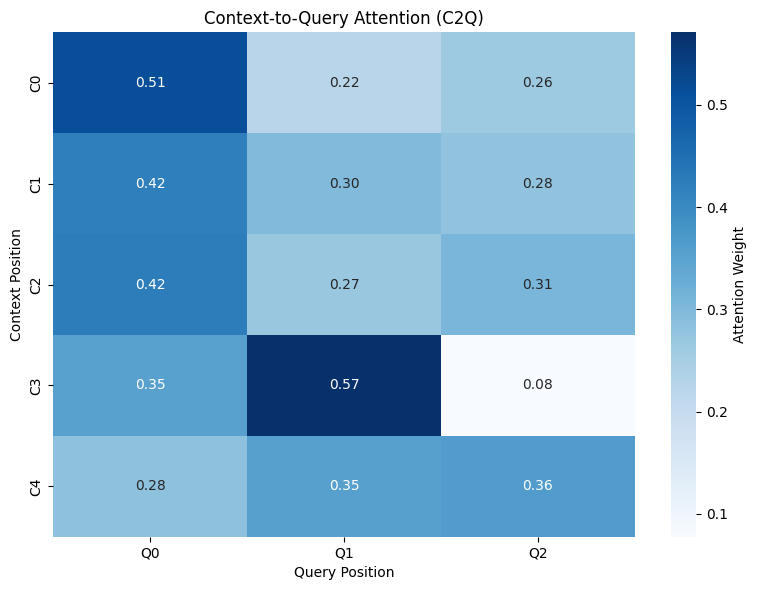

Each row shows which query words a context word attends to.
Rows sum to 1.0 (softmax over query dimension).


In [8]:
# Create small example for visualization
context_small = torch.randn(1, 5, hidden_size)
query_small = torch.randn(1, 3, hidden_size)

# Compute similarity matrix
S = attn_flow.compute_similarity(context_small, query_small)
c2q_attn = F.softmax(S, dim=-1)

# Plot C2Q attention
plt.figure(figsize=(8, 6))
sns.heatmap(c2q_attn[0].detach().numpy(), 
            annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'Q{i}' for i in range(3)],
            yticklabels=[f'C{i}' for i in range(5)],
            cbar_kws={'label': 'Attention Weight'})
plt.title('Context-to-Query Attention (C2Q)')
plt.xlabel('Query Position')
plt.ylabel('Context Position')
plt.tight_layout()
plt.show()

print("Each row shows which query words a context word attends to.")
print("Rows sum to 1.0 (softmax over query dimension).")

Build the complete BiDAF model.

In [9]:
class SimplifiedBiDAF(nn.Module):
    """Simplified BiDAF model for extractive QA."""
    
    def __init__(self, vocab_size: int, embed_size: int = 100, hidden_size: int = 128):
        super().__init__()
        self.embed_size = embed_size
        self.hidden_size = hidden_size
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        
        # Contextual encoding (BiLSTM)
        self.context_lstm = nn.LSTM(embed_size, hidden_size // 2, 
                                     bidirectional=True, batch_first=True)
        self.query_lstm = nn.LSTM(embed_size, hidden_size // 2,
                                   bidirectional=True, batch_first=True)
        
        # Attention flow
        self.attention_flow = AttentionFlow(hidden_size)
        
        # Modeling layer (processes attended representations)
        self.modeling_lstm = nn.LSTM(4 * hidden_size, hidden_size // 2,
                                      bidirectional=True, batch_first=True,
                                      num_layers=2, dropout=0.2)
        
        # Output layers for start and end positions
        self.start_linear = nn.Linear(hidden_size, 1)
        self.end_linear = nn.Linear(hidden_size, 1)
    
    def forward(self, context_ids: torch.Tensor, query_ids: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.
        
        Args:
            context_ids: (batch, context_len)
            query_ids: (batch, query_len)
        
        Returns:
            start_logits: (batch, context_len)
            end_logits: (batch, context_len)
        """
        # Embed
        context_embed = self.embedding(context_ids)  # (batch, context_len, embed_size)
        query_embed = self.embedding(query_ids)      # (batch, query_len, embed_size)
        
        # Contextual encoding
        context_enc, _ = self.context_lstm(context_embed)  # (batch, context_len, hidden_size)
        query_enc, _ = self.query_lstm(query_embed)        # (batch, query_len, hidden_size)
        
        # Attention flow
        attended = self.attention_flow(context_enc, query_enc)  # (batch, context_len, 4*hidden_size)
        
        # Modeling layer
        modeled, _ = self.modeling_lstm(attended)  # (batch, context_len, hidden_size)
        
        # Output layers
        start_logits = self.start_linear(modeled).squeeze(-1)  # (batch, context_len)
        end_logits = self.end_linear(modeled).squeeze(-1)      # (batch, context_len)
        
        return start_logits, end_logits

# Test model
vocab_size = 1000
model = SimplifiedBiDAF(vocab_size, embed_size=50, hidden_size=64)

# Create dummy input
batch_size = 2
context_len = 20
query_len = 8
context_ids = torch.randint(1, vocab_size, (batch_size, context_len))
query_ids = torch.randint(1, vocab_size, (batch_size, query_len))

start_logits, end_logits = model(context_ids, query_ids)

print(f"Context IDs shape: {context_ids.shape}")
print(f"Query IDs shape: {query_ids.shape}")
print(f"Start logits shape: {start_logits.shape}")
print(f"End logits shape: {end_logits.shape}")
print(f"\nModel has {sum(p.numel() for p in model.parameters()):,} parameters")

Context IDs shape: torch.Size([2, 20])
Query IDs shape: torch.Size([2, 8])
Start logits shape: torch.Size([2, 20])
End logits shape: torch.Size([2, 20])

Model has 192,658 parameters


## 4. BERT for Question Answering

### Why BERT is Perfect for QA

**BERT** (Bidirectional Encoder Representations from Transformers) revolutionized QA:

**Advantages:**
1. **Bidirectional context**: Sees full context in both directions
2. **Pre-trained representations**: Learned from massive text corpora
3. **Simple fine-tuning**: Just add two linear layers (start/end)
4. **State-of-the-art**: Achieved human-level performance on SQuAD

**Input format:**
```
[CLS] question tokens [SEP] context tokens [SEP]
```

**Output:**
- Linear layer on each token → start scores
- Another linear layer → end scores
- Loss: cross-entropy on true positions

Load pre-trained BERT for QA.

In [10]:
# Load BERT tokenizer and model
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')
bert_model = BertForQuestionAnswering.from_pretrained('bert-base-uncased')
bert_model = bert_model.to(device)
bert_model.eval()

print(f"Loaded BERT model with {sum(p.numel() for p in bert_model.parameters()):,} parameters")
print(f"Vocabulary size: {tokenizer.vocab_size:,}")

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded BERT model with 108,893,186 parameters
Vocabulary size: 30,522


Create a helper function to prepare inputs for BERT.

In [11]:
def prepare_bert_input(question: str, context: str, tokenizer) -> Dict[str, torch.Tensor]:
    """
    Prepare input for BERT QA model.
    
    Args:
        question: Question text
        context: Context text
        tokenizer: BERT tokenizer
    
    Returns:
        Dictionary with input_ids, attention_mask, token_type_ids
    """
    # Tokenize and encode
    encoding = tokenizer(
        question,
        context,
        add_special_tokens=True,
        max_length=384,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    
    return {
        'input_ids': encoding['input_ids'].to(device),
        'attention_mask': encoding['attention_mask'].to(device),
        'token_type_ids': encoding['token_type_ids'].to(device)
    }

# Test on example
example = qa_data[0]
inputs = prepare_bert_input(example.question, example.context, tokenizer)

print(f"Input IDs shape: {inputs['input_ids'].shape}")
print(f"Attention mask shape: {inputs['attention_mask'].shape}")
print(f"Token type IDs shape: {inputs['token_type_ids'].shape}")
print(f"\nFirst 20 tokens: {tokenizer.convert_ids_to_tokens(inputs['input_ids'][0][:20].cpu())}")

Input IDs shape: torch.Size([1, 384])
Attention mask shape: torch.Size([1, 384])
Token type IDs shape: torch.Size([1, 384])

First 20 tokens: ['[CLS]', 'when', 'was', 'the', 'e', '##iff', '##el', 'tower', 'completed', '?', '[SEP]', 'the', 'e', '##iff', '##el', 'tower', 'was', 'completed', 'in', '1889']


### Running Inference with BERT

To get predictions:
1. Pass inputs through BERT
2. Get start and end logits
3. Find positions with highest scores
4. Extract answer span from context

Implement answer extraction from BERT outputs.

In [12]:
def extract_answer(question: str, context: str, model, tokenizer, max_answer_length: int = 30) -> Tuple[str, float]:
    """
    Extract answer from context using BERT.
    
    Args:
        question: Question text
        context: Context text
        model: BERT QA model
        tokenizer: BERT tokenizer
        max_answer_length: Maximum answer length in tokens
    
    Returns:
        answer: Predicted answer text
        confidence: Confidence score
    """
    # Prepare input
    inputs = prepare_bert_input(question, context, tokenizer)
    
    # Get predictions
    with torch.no_grad():
        outputs = model(**inputs)
        start_logits = outputs.start_logits[0]  # (seq_len,)
        end_logits = outputs.end_logits[0]      # (seq_len,)
    
    # Get token IDs and find context start
    input_ids = inputs['input_ids'][0]
    token_type_ids = inputs['token_type_ids'][0]
    
    # Context tokens have token_type_id = 1
    context_start = (token_type_ids == 1).nonzero(as_tuple=True)[0][0].item()
    context_end = len(input_ids) - 1
    
    # Find best valid span
    best_score = -float('inf')
    best_start = context_start
    best_end = context_start
    
    for start_idx in range(context_start, context_end + 1):
        for end_idx in range(start_idx, min(start_idx + max_answer_length, context_end + 1)):
            score = start_logits[start_idx] + end_logits[end_idx]
            if score > best_score:
                best_score = score
                best_start = start_idx
                best_end = end_idx
    
    # Extract answer tokens
    answer_tokens = input_ids[best_start:best_end + 1]
    answer = tokenizer.decode(answer_tokens, skip_special_tokens=True)
    
    # Compute confidence (softmax over start and end separately)
    start_probs = F.softmax(start_logits, dim=0)
    end_probs = F.softmax(end_logits, dim=0)
    confidence = (start_probs[best_start] * end_probs[best_end]).item()
    
    return answer, confidence

# Test on examples
print("BERT QA Results:")
print("=" * 80)
for i, example in enumerate(qa_data[:3]):
    answer, confidence = extract_answer(example.question, example.context, bert_model, tokenizer)
    print(f"\nExample {i}:")
    print(f"Question: {example.question}")
    print(f"Context: {example.context}")
    print(f"True answer: '{example.answer_text}'")
    print(f"Predicted: '{answer}' (confidence: {confidence:.4f})")

BERT QA Results:



Example 0:
Question: When was the Eiffel Tower completed?
Context: The Eiffel Tower was completed in 1889 for the World's Fair in Paris.
True answer: '1889'
Predicted: '1889 for the world ' s fair in paris.' (confidence: 0.0000)



Example 1:
Question: Where is the Eiffel Tower located?
Context: The Eiffel Tower was completed in 1889 for the World's Fair in Paris.
True answer: 'Paris'
Predicted: '1889 for the world ' s fair in paris.' (confidence: 0.0000)



Example 2:
Question: Who created Python?
Context: Python was created by Guido van Rossum in 1991 as a high-level programming language.
True answer: 'Guido van Rossum'
Predicted: 'by guido van rossum in 1991 as' (confidence: 0.0000)


## 5. Training Data Preparation

### Creating a Custom QA Dataset

To train a QA model, we need:
1. Tokenized inputs (question + context)
2. Start and end position labels
3. Proper padding and batching

For BERT, we must find the token positions corresponding to character positions in the original text.

Create a PyTorch dataset for QA.

In [13]:
class QADataset(Dataset):
    """Dataset for extractive QA."""
    
    def __init__(self, examples: List[QAExample], tokenizer, max_length: int = 384):
        self.examples = examples
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self) -> int:
        return len(self.examples)
    
    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        example = self.examples[idx]
        
        # Tokenize
        encoding = self.tokenizer(
            example.question,
            example.context,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_offsets_mapping=True,  # Character offsets for each token
            return_tensors='pt'
        )
        
        # Find start and end token positions
        offset_mapping = encoding.pop('offset_mapping')[0]
        token_type_ids = encoding['token_type_ids'][0]
        
        # Find context tokens (token_type_id = 1)
        context_mask = token_type_ids == 1
        
        # Find answer span in tokens
        start_char = example.answer_start
        end_char = example.answer_end
        
        start_token = 0
        end_token = 0
        
        for i, (offset_start, offset_end) in enumerate(offset_mapping):
            if not context_mask[i]:
                continue
            
            # Adjust offsets (they're relative to question+context, need context-only)
            # This is approximate - in practice, use char_to_token from tokenizer
            if offset_start <= start_char < offset_end:
                start_token = i
            if offset_start < end_char <= offset_end:
                end_token = i
        
        # If we couldn't find the answer, use CLS token (for impossible questions)
        if start_token == 0 and end_token == 0:
            start_token = 0
            end_token = 0
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'token_type_ids': encoding['token_type_ids'].squeeze(0),
            'start_positions': torch.tensor(start_token),
            'end_positions': torch.tensor(end_token)
        }

# Create dataset
qa_dataset = QADataset(qa_data, tokenizer)

print(f"Dataset size: {len(qa_dataset)}")
print(f"\nSample item:")
sample = qa_dataset[0]
for key, value in sample.items():
    if isinstance(value, torch.Tensor):
        print(f"{key}: shape={value.shape}, dtype={value.dtype}")
        if key == 'start_positions' or key == 'end_positions':
            print(f"  value={value.item()}")

Dataset size: 6

Sample item:
input_ids: shape=torch.Size([384]), dtype=torch.int64
attention_mask: shape=torch.Size([384]), dtype=torch.int64
token_type_ids: shape=torch.Size([384]), dtype=torch.int64
start_positions: shape=torch.Size([]), dtype=torch.int64
  value=0
end_positions: shape=torch.Size([]), dtype=torch.int64
  value=19


Create a data loader for batching.

In [14]:
# Create data loader
qa_loader = DataLoader(qa_dataset, batch_size=2, shuffle=True)

# Test batch
batch = next(iter(qa_loader))
print("Batch contents:")
for key, value in batch.items():
    print(f"{key}: {value.shape}")

print(f"\nStart positions: {batch['start_positions']}")
print(f"End positions: {batch['end_positions']}")

Batch contents:
input_ids: torch.Size([2, 384])
attention_mask: torch.Size([2, 384])
token_type_ids: torch.Size([2, 384])
start_positions: torch.Size([2])
end_positions: torch.Size([2])

Start positions: tensor([ 0, 16])
End positions: tensor([19,  0])


## 6. Training Loop (Simplified)

### Training Objective

The loss function for QA is simple:
- **Start loss**: Cross-entropy between predicted start logits and true start position
- **End loss**: Cross-entropy between predicted end logits and true end position
- **Total loss**: Sum of start and end losses

This treats position prediction as a classification problem over all tokens.

Implement training loop (demonstration only - not actually training due to small dataset).

In [15]:
def train_step(model, batch, optimizer):
    """
    Single training step.
    
    Args:
        model: QA model
        batch: Batch of data
        optimizer: Optimizer
    
    Returns:
        loss: Training loss
    """
    model.train()
    
    # Forward pass
    outputs = model(
        input_ids=batch['input_ids'],
        attention_mask=batch['attention_mask'],
        token_type_ids=batch['token_type_ids'],
        start_positions=batch['start_positions'],
        end_positions=batch['end_positions']
    )
    
    loss = outputs.loss
    
    # Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    return loss.item()

# Demonstrate training step (not actual training)
# In practice, you would fine-tune on SQuAD for several epochs
demo_model = BertForQuestionAnswering.from_pretrained('bert-base-uncased').to(device)
optimizer = torch.optim.AdamW(demo_model.parameters(), lr=3e-5)

# Single step demonstration
batch = next(iter(qa_loader))
batch = {k: v.to(device) for k, v in batch.items()}
loss = train_step(demo_model, batch, optimizer)

print(f"Single training step completed")
print(f"Loss: {loss:.4f}")
print(f"\nNote: Actual training requires SQuAD dataset and multiple epochs.")

Some weights of BertForQuestionAnswering were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['qa_outputs.bias', 'qa_outputs.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Single training step completed
Loss: 6.0664

Note: Actual training requires SQuAD dataset and multiple epochs.


## 7. Answer Decoding & Postprocessing

### Finding the Best Answer Span

After getting start and end logits, we need to:
1. **Ensure validity**: Start must be ≤ end
2. **Apply length constraints**: Limit maximum span length
3. **Handle impossible questions**: Detect when no answer exists
4. **Compute confidence**: Use probabilities for ranking

The naive approach of taking argmax(start) and argmax(end) can give invalid spans.

Implement robust answer decoding.

In [16]:
def decode_answer(
    start_logits: torch.Tensor,
    end_logits: torch.Tensor,
    input_ids: torch.Tensor,
    tokenizer,
    max_answer_length: int = 30,
    null_threshold: float = 0.0
) -> Tuple[str, float, int, int]:
    """
    Decode answer from logits with proper constraints.
    
    Args:
        start_logits: (seq_len,) Start position logits
        end_logits: (seq_len,) End position logits
        input_ids: (seq_len,) Input token IDs
        tokenizer: Tokenizer for decoding
        max_answer_length: Maximum answer length in tokens
        null_threshold: Threshold for impossible questions
    
    Returns:
        answer: Decoded answer text
        confidence: Confidence score
        start_idx: Start token index
        end_idx: End token index
    """
    # Find CLS token position (for null answers)
    cls_score = start_logits[0] + end_logits[0]
    
    # Find best valid span
    best_score = cls_score
    best_start = 0
    best_end = 0
    
    seq_len = len(start_logits)
    
    for start_idx in range(1, seq_len):  # Skip CLS token
        for end_idx in range(start_idx, min(start_idx + max_answer_length, seq_len)):
            score = start_logits[start_idx] + end_logits[end_idx]
            if score > best_score:
                best_score = score
                best_start = start_idx
                best_end = end_idx
    
    # Check if question is impossible
    if best_start == 0 or (best_score - cls_score) < null_threshold:
        return "", 0.0, 0, 0
    
    # Decode answer
    answer_tokens = input_ids[best_start:best_end + 1]
    answer = tokenizer.decode(answer_tokens, skip_special_tokens=True)
    
    # Compute confidence
    start_probs = F.softmax(start_logits, dim=0)
    end_probs = F.softmax(end_logits, dim=0)
    confidence = (start_probs[best_start] * end_probs[best_end]).item()
    
    return answer, confidence, best_start, best_end

# Test decoding
example = qa_data[0]
inputs = prepare_bert_input(example.question, example.context, tokenizer)

with torch.no_grad():
    outputs = bert_model(**inputs)
    start_logits = outputs.start_logits[0]
    end_logits = outputs.end_logits[0]

answer, confidence, start_idx, end_idx = decode_answer(
    start_logits, end_logits, inputs['input_ids'][0], tokenizer
)

print(f"Question: {example.question}")
print(f"True answer: {example.answer_text}")
print(f"Predicted: {answer}")
print(f"Confidence: {confidence:.4f}")
print(f"Token positions: {start_idx}-{end_idx}")

Question: When was the Eiffel Tower completed?
True answer: 1889
Predicted: 1889 for the world ' s fair in paris.
Confidence: 0.0000
Token positions: 19-39


Visualize the score distribution.

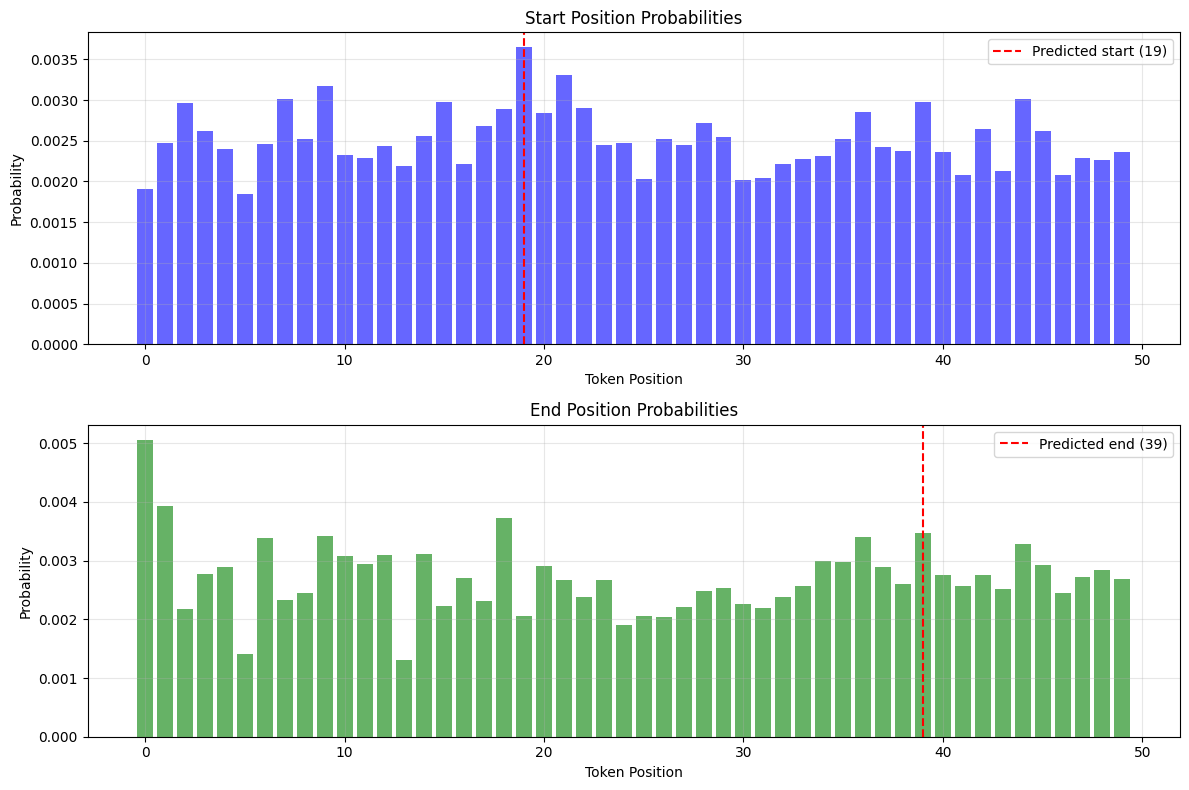


The model assigns high probability to positions 19 (start) and 39 (end).


In [17]:
# Visualize start and end score distributions
start_probs = F.softmax(start_logits, dim=0).cpu().numpy()
end_probs = F.softmax(end_logits, dim=0).cpu().numpy()

# Show only first 50 positions for clarity
show_len = min(50, len(start_probs))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Start probabilities
ax1.bar(range(show_len), start_probs[:show_len], alpha=0.6, color='blue')
ax1.axvline(start_idx, color='red', linestyle='--', label=f'Predicted start ({start_idx})')
ax1.set_xlabel('Token Position')
ax1.set_ylabel('Probability')
ax1.set_title('Start Position Probabilities')
ax1.legend()
ax1.grid(True, alpha=0.3)

# End probabilities
ax2.bar(range(show_len), end_probs[:show_len], alpha=0.6, color='green')
ax2.axvline(end_idx, color='red', linestyle='--', label=f'Predicted end ({end_idx})')
ax2.set_xlabel('Token Position')
ax2.set_ylabel('Probability')
ax2.set_title('End Position Probabilities')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nThe model assigns high probability to positions {start_idx} (start) and {end_idx} (end).")

## 8. Evaluation Metrics

### Exact Match (EM) and F1 Score

QA systems are evaluated using two metrics:

**Exact Match (EM):**
- 1 if prediction matches ground truth exactly (after normalization)
- 0 otherwise
- Very strict metric

**F1 Score:**
- Token-level overlap between prediction and ground truth
- Precision: What fraction of predicted tokens are correct?
- Recall: What fraction of true tokens were predicted?
- F1 = 2 × (Precision × Recall) / (Precision + Recall)
- More lenient than EM

Implement normalization for fair comparison.

In [18]:
def normalize_answer(text: str) -> str:
    """
    Normalize answer text for evaluation.
    
    - Lowercase
    - Remove punctuation
    - Remove articles (a, an, the)
    - Remove extra whitespace
    """
    # Lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove articles
    text = re.sub(r'\b(a|an|the)\b', ' ', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text.strip()

# Test normalization
examples = [
    "The Eiffel Tower",
    "eiffel tower",
    "the eiffel tower.",
    "an answer"
]

print("Normalization examples:")
for ex in examples:
    normalized = normalize_answer(ex)
    print(f"'{ex}' -> '{normalized}'")

Normalization examples:
'The Eiffel Tower' -> 'eiffel tower'
'eiffel tower' -> 'eiffel tower'
'the eiffel tower.' -> 'eiffel tower'
'an answer' -> 'answer'


Implement EM and F1 metrics.

In [19]:
def compute_exact_match(prediction: str, ground_truth: str) -> float:
    """Compute exact match score (0 or 1)."""
    return float(normalize_answer(prediction) == normalize_answer(ground_truth))

def compute_f1(prediction: str, ground_truth: str) -> float:
    """
    Compute F1 score based on token overlap.
    
    Returns:
        f1: F1 score between 0 and 1
    """
    pred_tokens = normalize_answer(prediction).split()
    truth_tokens = normalize_answer(ground_truth).split()
    
    # Handle empty predictions
    if len(pred_tokens) == 0 or len(truth_tokens) == 0:
        return float(pred_tokens == truth_tokens)
    
    # Count common tokens
    common = Counter(pred_tokens) & Counter(truth_tokens)
    num_common = sum(common.values())
    
    if num_common == 0:
        return 0.0
    
    # Compute precision and recall
    precision = num_common / len(pred_tokens)
    recall = num_common / len(truth_tokens)
    
    # Compute F1
    f1 = 2 * (precision * recall) / (precision + recall)
    return f1

# Test metrics
test_cases = [
    ("1889", "1889", True),
    ("the year 1889", "1889", False),
    ("Paris, France", "Paris", False),
]

print("Metric examples:")
print("=" * 80)
for pred, truth, _ in test_cases:
    em = compute_exact_match(pred, truth)
    f1 = compute_f1(pred, truth)
    print(f"\nPrediction: '{pred}'")
    print(f"Ground truth: '{truth}'")
    print(f"EM: {em:.2f}, F1: {f1:.2f}")

Metric examples:

Prediction: '1889'
Ground truth: '1889'
EM: 1.00, F1: 1.00

Prediction: 'the year 1889'
Ground truth: '1889'
EM: 0.00, F1: 0.67

Prediction: 'Paris, France'
Ground truth: 'Paris'
EM: 0.00, F1: 0.67


Evaluate BERT on our examples.

In [20]:
# Evaluate on all examples
em_scores = []
f1_scores = []

print("Evaluation Results:")
print("=" * 80)

for i, example in enumerate(qa_data):
    # Get prediction
    pred_answer, confidence = extract_answer(
        example.question, example.context, bert_model, tokenizer
    )
    
    # Compute metrics
    em = compute_exact_match(pred_answer, example.answer_text)
    f1 = compute_f1(pred_answer, example.answer_text)
    
    em_scores.append(em)
    f1_scores.append(f1)
    
    print(f"\nExample {i}:")
    print(f"Q: {example.question}")
    print(f"True: '{example.answer_text}'")
    print(f"Pred: '{pred_answer}' (conf={confidence:.3f})")
    print(f"EM: {em:.2f}, F1: {f1:.2f}")

# Overall metrics
print("\n" + "=" * 80)
print(f"Average EM: {np.mean(em_scores):.3f}")
print(f"Average F1: {np.mean(f1_scores):.3f}")

Evaluation Results:



Example 0:
Q: When was the Eiffel Tower completed?
True: '1889'
Pred: '1889 for the world ' s fair in paris.' (conf=0.000)
EM: 0.00, F1: 0.25



Example 1:
Q: Where is the Eiffel Tower located?
True: 'Paris'
Pred: '1889 for the world ' s fair in paris.' (conf=0.000)
EM: 0.00, F1: 0.25



Example 2:
Q: Who created Python?
True: 'Guido van Rossum'
Pred: 'by guido van rossum in 1991 as' (conf=0.000)
EM: 0.00, F1: 0.60



Example 3:
Q: When was Python created?
True: '1991'
Pred: 'by guido van rossum in 1991 as' (conf=0.000)
EM: 0.00, F1: 0.25



Example 4:
Q: When was the Transformer introduced?
True: '2017'
Pred: '##er architecture was' (conf=0.000)
EM: 0.00, F1: 0.00



Example 5:
Q: Where were the Transformer researchers from?
True: 'Google'
Pred: '##er architecture was' (conf=0.000)
EM: 0.00, F1: 0.00

Average EM: 0.000
Average F1: 0.225


Visualize metric distribution.

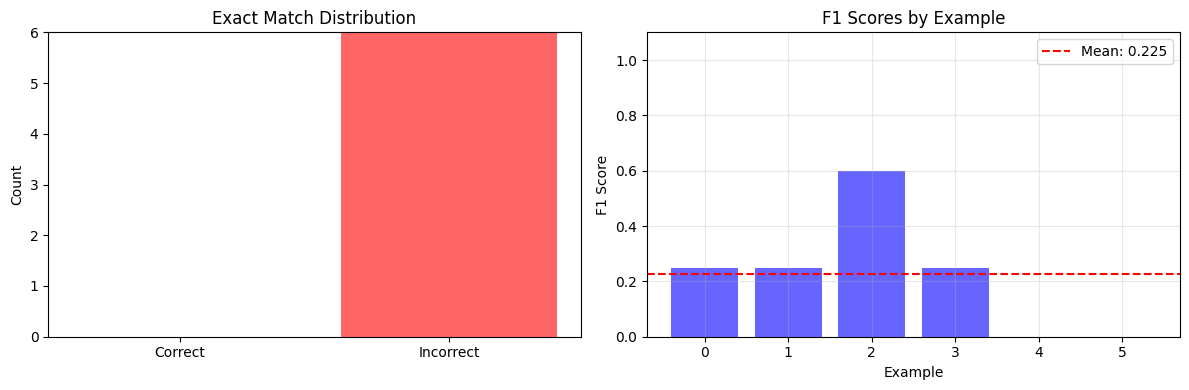

In [21]:
# Plot metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# EM distribution
ax1.bar(['Correct', 'Incorrect'], 
        [sum(em_scores), len(em_scores) - sum(em_scores)],
        color=['green', 'red'], alpha=0.6)
ax1.set_ylabel('Count')
ax1.set_title('Exact Match Distribution')
ax1.set_ylim([0, len(em_scores)])

# F1 scores
ax2.bar(range(len(f1_scores)), f1_scores, color='blue', alpha=0.6)
ax2.axhline(np.mean(f1_scores), color='red', linestyle='--', label=f'Mean: {np.mean(f1_scores):.3f}')
ax2.set_xlabel('Example')
ax2.set_ylabel('F1 Score')
ax2.set_title('F1 Scores by Example')
ax2.set_ylim([0, 1.1])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Handling Impossible Questions (SQuAD 2.0)

### The Impossible Question Problem

**SQuAD 2.0** introduced questions that cannot be answered from the context. This requires models to:
1. Detect when no answer exists
2. Return null/empty string
3. Provide confidence scores

**Approach:**
- Use the `[CLS]` token as a "null answer" indicator
- Compare CLS score to best span score
- If CLS score is higher, predict "no answer"

Create examples with impossible questions.

In [22]:
# Create impossible question examples
impossible_questions = [
    (
        "The Eiffel Tower was completed in 1889 for the World's Fair in Paris.",
        "How tall is the Eiffel Tower?",  # Not mentioned in context
        False
    ),
    (
        "Python was created by Guido van Rossum in 1991 as a high-level programming language.",
        "When was the Eiffel Tower built?",  # Wrong context
        False
    ),
    (
        "The Transformer architecture was introduced in 2017 by researchers at Google.",
        "When was the Transformer introduced?",  # Answerable
        True
    ),
]

print("Testing impossible question detection:")
print("=" * 80)

for i, (context, question, answerable) in enumerate(impossible_questions):
    answer, confidence = extract_answer(question, context, bert_model, tokenizer)
    
    print(f"\nExample {i}:")
    print(f"Q: {question}")
    print(f"Context: {context[:60]}...")
    print(f"Expected: {'answerable' if answerable else 'impossible'}")
    print(f"Predicted: '{answer}' (conf={confidence:.4f})")
    print(f"Status: {'✓' if (bool(answer) == answerable) else '✗'}")

Testing impossible question detection:



Example 0:
Q: How tall is the Eiffel Tower?
Context: The Eiffel Tower was completed in 1889 for the World's Fair ...
Expected: impossible
Predicted: '1889 for the world ' s fair in paris.' (conf=0.0000)
Status: ✗



Example 1:
Q: When was the Eiffel Tower built?
Context: Python was created by Guido van Rossum in 1991 as a high-lev...
Expected: impossible
Predicted: 'by guido van rossum in 1991 as' (conf=0.0000)
Status: ✗



Example 2:
Q: When was the Transformer introduced?
Context: The Transformer architecture was introduced in 2017 by resea...
Expected: answerable
Predicted: '##er architecture was' (conf=0.0000)
Status: ✓


### Threshold Tuning

The threshold for detecting impossible questions is crucial:
- Too low: Predict answers for impossible questions (false positives)
- Too high: Refuse to answer answerable questions (false negatives)

In practice, this threshold is tuned on a validation set to balance precision and recall.

## 10. Advanced Topics

### Multi-Hop Question Answering

**Multi-hop QA** requires reasoning across multiple pieces of information:

**Example:**
- Context 1: "Einstein was born in Germany."
- Context 2: "The scientist who developed relativity won the Nobel Prize."
- Question: "Where was the Nobel Prize winner born?"

**Approaches:**
1. Graph-based reasoning (entity linking)
2. Iterative retrieval (follow reasoning chain)
3. End-to-end transformers (process all contexts)

Create a simple multi-hop example.

In [23]:
# Multi-hop reasoning example (simplified)
multihop_context = """Einstein was born in Germany in 1879. 
He developed the theory of relativity. 
The scientist who developed relativity won the Nobel Prize in 1921."""

multihop_questions = [
    "Where was Einstein born?",  # Single-hop
    "When did the scientist who developed relativity win the Nobel Prize?",  # Multi-hop
]

print("Multi-hop QA examples:")
print("=" * 80)
print(f"Context: {multihop_context}\n")

for i, question in enumerate(multihop_questions):
    answer, confidence = extract_answer(question, multihop_context, bert_model, tokenizer)
    print(f"Q{i+1}: {question}")
    print(f"A: {answer} (conf={confidence:.4f})\n")

Multi-hop QA examples:
Context: Einstein was born in Germany in 1879. 
He developed the theory of relativity. 
The scientist who developed relativity won the Nobel Prize in 1921.



Q1: Where was Einstein born?
A: germany in 1879. he developed the (conf=0.0000)



Q2: When did the scientist who developed relativity win the Nobel Prize?
A: germany in 1879. he developed the (conf=0.0000)



### Open-Domain Question Answering

**Open-domain QA** doesn't provide the context - the system must:
1. **Retrieve** relevant documents from a large corpus
2. **Read** the documents to extract answers

**Architecture:**
- Retriever: Dense retrieval (DPR, ANCE) or sparse (BM25, TF-IDF)
- Reader: Extractive QA model (BERT, RoBERTa)
- Re-ranker: Optional component to improve top results

**Examples:** DrQA, ORQA, DPR, RAG

Simulate a simple retrieval + reading pipeline.

In [24]:
# Simulate open-domain QA
document_corpus = [
    "The Eiffel Tower was completed in 1889 for the World's Fair in Paris.",
    "Python was created by Guido van Rossum in 1991 as a high-level programming language.",
    "The Transformer architecture was introduced in 2017 by researchers at Google.",
    "Deep learning uses neural networks with multiple layers to learn representations.",
    "BERT is a transformer-based model for natural language understanding.",
]

def open_domain_qa(question: str, corpus: List[str], top_k: int = 3) -> str:
    """
    Simple open-domain QA: retrieve + read.
    
    Args:
        question: Question text
        corpus: List of documents
        top_k: Number of documents to retrieve
    
    Returns:
        answer: Best answer from top documents
    """
    # Retrieval: use TF-IDF baseline
    retriever = TfidfQABaseline()
    retriever.fit(corpus)
    
    # Rank documents by similarity
    q_vec = retriever.get_tfidf_vector(question)
    scores = []
    for doc in corpus:
        d_vec = retriever.get_tfidf_vector(doc)
        score = retriever.cosine_similarity(q_vec, d_vec)
        scores.append(score)
    
    # Get top-k documents
    top_indices = np.argsort(scores)[-top_k:][::-1]
    top_docs = [corpus[i] for i in top_indices]
    
    # Reading: run QA on each document
    best_answer = ""
    best_confidence = 0.0
    
    for doc in top_docs:
        answer, confidence = extract_answer(question, doc, bert_model, tokenizer)
        if confidence > best_confidence:
            best_answer = answer
            best_confidence = confidence
    
    return best_answer

# Test open-domain QA
test_questions = [
    "When was Python created?",
    "Who introduced the Transformer?",
    "What is BERT?",
]

print("Open-Domain QA Results:")
print("=" * 80)
for question in test_questions:
    answer = open_domain_qa(question, document_corpus)
    print(f"Q: {question}")
    print(f"A: {answer}\n")

Open-Domain QA Results:


Q: When was Python created?
A: by guido van rossum in 1991 as



Q: Who introduced the Transformer?
A: 1889 for the world ' s fair in paris.



Q: What is BERT?
A: with



### Conversational QA

**Conversational QA** handles follow-up questions in dialogue:

**Example:**
- Q1: "When was the Eiffel Tower built?"
- A1: "1889"
- Q2: "Where?"
- A2: "Paris"

**Challenges:**
- Coreference resolution ("it", "he", "there")
- Context from previous turns
- Answer span may depend on dialogue history

**Datasets:** CoQA, QuAC

## 11. Key Takeaways

### Summary

**Core Concepts:**
1. **Task Definition**: Extractive QA finds answer spans in context (vs. generating new text)
2. **BiDAF**: Bidirectional attention flow enables context-query and query-context interactions
3. **BERT for QA**: Pre-trained transformers + linear layers achieve SOTA results
4. **Evaluation**: EM (strict) and F1 (lenient) metrics measure performance
5. **Impossible Questions**: CLS token score detects unanswerable questions

**Key Insights:**
- Bidirectional attention is crucial for understanding question-context relationships
- Start and end positions are predicted independently, then combined
- Proper decoding with constraints (start ≤ end, max length) is essential
- Pre-trained models dramatically outperform task-specific architectures
- Open-domain QA requires both retrieval and reading comprehension

**Practical Applications:**
- Search engines and document Q&A
- Customer support chatbots
- Information extraction systems
- Reading comprehension assessments

**Extensions:**
- Multi-hop reasoning (graph-based or iterative)
- Open-domain QA (retrieval + reading)
- Conversational QA (dialogue context)
- Generative QA (seq2seq models)